# 05 · From Screen to Shortlist — a target-ID walkthrough

**Audience:** a target-identification or translational team with a Perturb-seq screen and a cell state they want to reach.

**The question this notebook answers:** *I have a genome-scale knockdown screen and a target cell state. What should I put in my next screen, what can I actually drug, and what should I not waste an experiment on?*

Target and modality choices are made years before clinical outcomes are known. This notebook turns one screen into an earlier **decision**: a reachability **verdict**, a ranked **candidate panel**, a whole-direction mismatch **certificate**, and a **druggability + human-genetics dossier** for each nomination.

> **How this notebook computes.** The convex-cone fit on the full 6,871 × 10,282 screen takes several minutes per transition, so the 12-transition atlas and the 102-gene triage were computed offline and are **loaded here from `results/` (validated to reproduce the headline card to 1e-6)**. Fast primitives (a single masked fit, the closed-form null) run live so you can watch the method work. Every number shown is read from the repository's own result tables.

## 0 · Setup
Load the method module, the cached screen, and the pre-computed result tables.

In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# repo root (this notebook lives in notebooks/)
REPO = os.path.abspath("..")
sys.path.insert(0, REPO)
import reachability as rz
RESULTS = os.path.join(REPO, "results")

# cached screen: knockdown effect dictionary E (P perturbations x G readout genes) + targets
Z = np.load(os.path.join(REPO, "analysis_cache", "atlas_work", "inputs.npz"), allow_pickle=True)
E_Rest       = Z["E_Rest"].astype(float)          # (6871, 10282)
pert_names   = list(Z["gene_Rest"])               # perturbed gene per row
readout_names= list(Z["var_gene"])                # readout gene per column
d_Th1        = Z["t_toward_Th1"].astype(float)    # Th2 -> Th1 target shift

print(f"Screen E_Rest: {E_Rest.shape[0]:,} knockdown perturbations  x  {E_Rest.shape[1]:,} readout genes")
print(f"Target vector (Th2->Th1): {d_Th1.shape[0]:,} genes")

Screen E_Rest: 6,871 knockdown perturbations  x  10,282 readout genes
Target vector (Th2->Th1): 10,282 genes


## 1 · The idea in one picture

Each row of the screen is a **measured move**: what knocking down one gene does to the whole transcriptome. The method asks whether a **non-negative combination** of those moves can reproduce a desired shift `d` (from the current state toward the target state).

- If yes → the target is **reachable**, and the combination *is* the experimental recipe.
- If no → the method returns a **certificate**: the specific genes the target needs turned **up** that no knockdown mix can ever deliver (because knockdowns can only push in the directions they measured).

That "provably not, and here's why" is the part a correlation-ranked heatmap cannot give you.

## 2 · The screen → the verdict

We ask: starting from a **Th2** CD4⁺ T-cell, can a knockdown screen steer it toward **Th1**? The full-matrix result is loaded from the validated atlas; a fast **masked** fit is run live to show the machinery.

In [2]:
atlas = pd.read_csv(os.path.join(RESULTS, "atlas_reachability.csv"))
row = atlas[(atlas.target=="toward_Th1") & (atlas.condition=="Rest")].iloc[0]

print("Transition:  Th2  ->  Th1   (Rest condition)")
print(f"  Verdict                : {row.verdict}")
print(f"  In-sample cosine       : {row.reachable_cosine:.3f}   (how well the cone matches, on the genes it was fit on)")
print(f"  Held-out cosine        : {row.heldout_cosine:.3f}   (honest generalisation to unseen genes)")
print(f"  Significance (held-out): z = {row.heldout_z:.1f}   (vs a shuffled-target null; >~3 is significant)")

Transition:  Th2  ->  Th1   (Rest condition)
  Verdict                : PARTIALLY REACHABLE
  In-sample cosine       : 0.627   (how well the cone matches, on the genes it was fit on)
  Held-out cosine        : 0.446   (honest generalisation to unseen genes)
  Significance (held-out): z = 45.0   (vs a shuffled-target null; >~3 is significant)


In [3]:
# --- watch it work: a fast masked fit + the closed-form significance null (seconds, not minutes) ---
var  = E_Rest.var(axis=0)
mask = np.zeros(E_Rest.shape[1], bool); mask[np.argsort(var)[-400:]] = True   # 400 highest-variance readouts
fit  = rz.reachability(E_Rest, d_Th1, hvg_mask=mask)
anull= rz.analytic_anisotropy_null(E_Rest, d_Th1, hvg_mask=mask, held_out=True, observed=fit.reachable_cosine)
print(f"Live masked fit (400 genes): cosine = {fit.reachable_cosine:.3f}")
print(f"Closed-form null           : E[null]={anull.null_mean:.3f} +/- {anull.null_sd:.3f}  ->  z = {anull.z:.1f}")
print("(The masked fit overstates the full-genome cosine; the atlas above is the honest number.)")

Live masked fit (400 genes): cosine = 1.000
Closed-form null           : E[null]=0.060 +/- 0.054  ->  z = 17.3
(The masked fit overstates the full-genome cosine; the atlas above is the honest number.)


## 3 · The split that decides the modality

A reachable target is not automatically a **knockdown** target. The signed decomposition splits the required shift into three parts:

- **LOF** — the fraction a **loss-of-function** tool (CRISPRi / knockdown / degrader) can deliver.
- **GOF proxy** — the additional fraction matched by sign-flipped knockdown effects; this motivates, but does not measure, a CRISPRa arm.
- **neither** — the remainder matched by neither the measured LOF cone nor its sign-flipped proxy.

This is the number that tells a team *which technology* to bring.

Read-out: knockdown alone delivers 39% of the shift. Installing Th1 identity needs
activation (25%); 35% is beyond any single-gene move. 'Remove Th2' is feasible;
'install Th1' is not a pure-knockdown job.


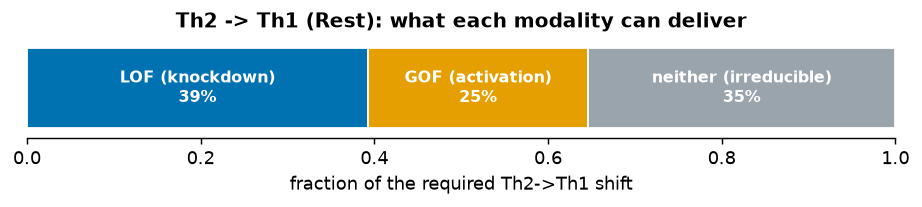

In [4]:
lof, gof, nei = float(row.lof_fraction), float(row.gof_fraction), float(row.neither_fraction)
fig, ax = plt.subplots(figsize=(7.2, 1.7))
left = 0.0
parts = [("LOF (knockdown)", lof, "#0072B2"),
         ("GOF (activation)", gof, "#E69F00"),
         ("neither (irreducible)", nei, "#9aa4ad")]
for label, frac, col in parts:
    ax.barh(0, frac, left=left, color=col, edgecolor="white")
    if frac > 0.05:
        ax.text(left + frac/2, 0, f"{label}\n{frac:.0%}", ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    left += frac
ax.set_xlim(0, 1); ax.set_ylim(-0.5, 0.5); ax.set_yticks([]); ax.set_xlabel("fraction of the required Th2->Th1 shift")
ax.set_title("Th2 -> Th1 (Rest): what each modality can deliver", fontsize=11, fontweight="bold")
for s in ("top","right","left"): ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

print(f"Read-out: knockdown alone delivers {lof:.0%} of the shift. Installing Th1 identity needs")
print(f"activation ({gof:.0%}); {nei:.0%} is beyond any single-gene move. 'Remove Th2' is feasible;")
print("'install Th1' is not a pure-knockdown job.")

## 4 · The recipe — what to put in the next screen

For the reachable (LOF) part, the greedy spectrum returns a **ranked, minimal knockdown recipe**: each gene is the next most informative perturbation to add, with the cumulative cosine it buys. The **knee** of this curve is the recommended library size for the next screen.

Ranked knockdown recipe (Th2 -> Th1):
 rank gene_knockdown cumulative_cosine marginal_gain
    1           LAT2             0.226        +0.226
    2         APPBP2             0.289        +0.064
    3           RARA             0.325        +0.035
    4           ICOS             0.356        +0.031
    5         SNAP23             0.379        +0.023
    6           SNX4             0.392        +0.013
    7          VTI1A             0.402        +0.010
    8         HEXIM1             0.412        +0.010


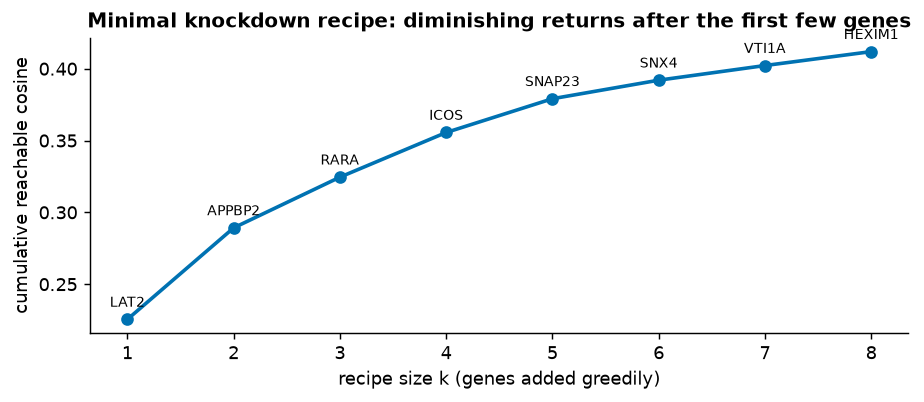

In [5]:
recipe = pd.read_csv(os.path.join(RESULTS, "table2_minimal_recipe.csv"))
show = recipe.head(8)[["rank","gene_knockdown","cumulative_cosine"]].copy()
show["marginal_gain"] = show["cumulative_cosine"].diff().fillna(show["cumulative_cosine"])
print("Ranked knockdown recipe (Th2 -> Th1):")
print(show.to_string(index=False, formatters={"cumulative_cosine":"{:.3f}".format,"marginal_gain":"{:+.3f}".format}))

fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(show["rank"], show["cumulative_cosine"], "o-", color="#0072B2", lw=2)
for _, r in show.iterrows():
    ax.annotate(r["gene_knockdown"], (r["rank"], r["cumulative_cosine"]),
                textcoords="offset points", xytext=(0,7), ha="center", fontsize=8)
ax.set_xlabel("recipe size k (genes added greedily)"); ax.set_ylabel("cumulative reachable cosine")
ax.set_title("Minimal knockdown recipe: diminishing returns after the first few genes", fontsize=11, fontweight="bold")
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

## 5 · The certificate — when NOT to run a knockdown screen

This is the differentiator. The complete residual separates the target direction from the measured knockdown cone. Its largest positive coordinates show what the closest knockdown mixture still under-delivers. They are **CRISPRa or de-repression hypotheses**, not proof that activating an individual readout causes the target state.

In [6]:
cert = pd.read_csv(os.path.join(RESULTS, "table3_activation_certificate.csv"))
print("Unmet-readout hypotheses (positive coordinates of the full residual):")
print(cert.head(8).to_string(index=False, formatters={"target_zscore":"{:.1f}".format,"unmet_upward_demand":"{:.1f}".format}))
print()
print("Interpretation: LYAR, IKZF3, CRTAM, GBP5 ... are Th1-identity genes the target needs induced.")
print("Together they mark a knockdown-cone mismatch; test their intervention sign in a CRISPRa or de-repression arm.")

Unmet-readout hypotheses (positive coordinates of the full residual):
 rank   gene target_zscore unmet_upward_demand
    1   LYAR          31.3                20.9
    2  IKZF3          22.0                20.4
    3 TMEM62          25.4                20.4
    4  CRTAM          13.7                20.0
    5   STOM          30.5                18.3
    6  PLCB1          17.3                17.2
    7   CBLB          23.4                16.4
    8   GBP5          25.5                15.6

Interpretation: LYAR, IKZF3, CRTAM, GBP5 ... are Th1-identity genes the target needs induced.
Together they mark a knockdown-cone mismatch; test their intervention sign in a CRISPRa or de-repression arm.


## 6 · The target dossier — reachable × druggable × genetically supported

A gene being *reachable* is necessary but not sufficient. The full atlas nominated **102 genes** across the 12 transitions; each is cross-referenced against **Open Targets** tractability (can we drug it?) and **human genetics** (is it disease-linked?). Three buckets result:

- **GREEN-LIGHT** — reachable, druggable, *and* genetically supported. Start here.
- **REQUIRED-BUT-UNDRUGGABLE** — the method says you need it, but no conventional drug modality reaches it. Candidates for degraders / new modality, or a reason to pick a different node.
- **tractable-but-untried** — druggable and reachable, no genetic support yet.

Human genetic support is the single strongest predictor of clinical success — targets with it succeed at roughly **twice** the rate — so the green-light bucket is where a portfolio should concentrate.

In [7]:
modmap = pd.read_csv(os.path.join(RESULTS, "modality_intervention_map.csv"))
green = modmap[modmap.flag == "GREEN-LIGHT (druggable+genetic)"].sort_values("top_immune_genetic_score", ascending=False)

print(f"Nominated genes: {len(modmap)}   |   GREEN-LIGHT: {len(green)}   |   "
      f"REQUIRED-BUT-UNDRUGGABLE: {(modmap.flag=='REQUIRED-BUT-UNDRUGGABLE').sum()}")
print()
dossier = green[["gene","modality_tier","n_drugs_or_candidates","top_immune_disease","top_immune_genetic_score"]].copy()
dossier.columns = ["gene","druggability","n_drugs/candidates","top disease link","genetic score"]
print("GREEN-LIGHT target dossier (reachable + druggable + genetically supported):")
print(dossier.to_string(index=False, formatters={"genetic score":"{:.2f}".format}))

Nominated genes: 102   |   GREEN-LIGHT: 9   |   REQUIRED-BUT-UNDRUGGABLE: 45

GREEN-LIGHT target dossier (reachable + druggable + genetically supported):
  gene  druggability  n_drugs/candidates                     top disease link genetic score
  CD3D clinical drug                  16                  immunodeficiency 19          0.92
  ICOS clinical drug                   4 immunodeficiency, common variable, 1          0.83
  JAK2 clinical drug                  31                   ulcerative colitis          0.82
   CD5  AB-tractable                   1                   multiple sclerosis          0.72
IFNGR1  SM-tractable                   1             immunodeficiency disease          0.56
 CASP7 clinical drug                   1                             vitiligo          0.47
MAPK14 clinical drug                  28                   ulcerative colitis          0.42
VKORC1 clinical drug                   7                     Sjogren syndrome          0.28
 KEAP1 clinical dr

CD3D, ICOS, JAK2, MAPK14 already have clinical-grade drugs and strong immune-genetic support.


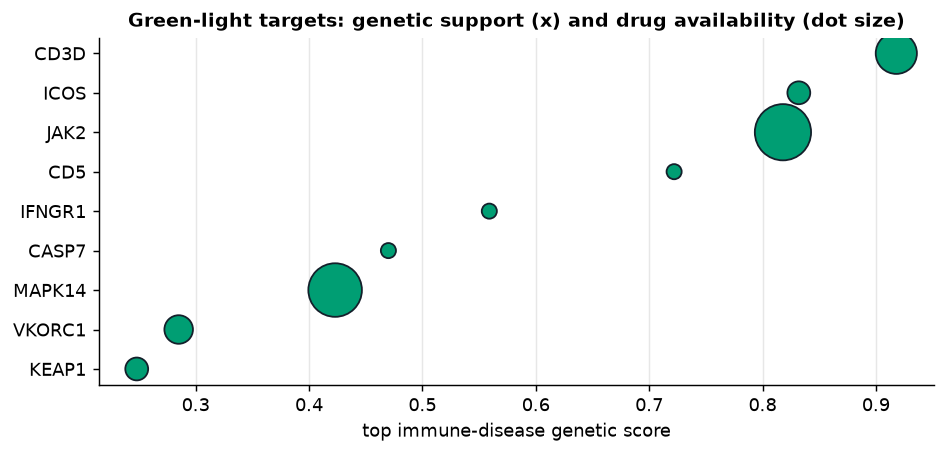

In [8]:
# visual: genetic support vs druggability for the green-light set
fig, ax = plt.subplots(figsize=(7.4, 3.6))
sizes = 40 + 30*green["n_drugs_or_candidates"].clip(upper=31)
ax.scatter(green["top_immune_genetic_score"], range(len(green)), s=sizes, color="#009E73", edgecolor="#14202b", zorder=3)
ax.set_yticks(range(len(green))); ax.set_yticklabels(green["gene"])
ax.invert_yaxis()
ax.set_xlabel("top immune-disease genetic score"); ax.set_title("Green-light targets: genetic support (x) and drug availability (dot size)", fontsize=10.5, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()
print("CD3D, ICOS, JAK2, MAPK14 already have clinical-grade drugs and strong immune-genetic support.")

## 7 · Bottom line for a target-ID team

For the **Th2 → Th1** transition in resting CD4⁺ T-cells, this single screen produced a complete, self-qualifying decision:

| Decision | Output |
|---|---|
| **Is it reachable?** | Partially — held-out cosine 0.448, above all 60 shuffled targets (plus-one empirical p = 1/61). |
| **By what modality?** | ~39% measured knockdown; ~25% sign-flipped GOF proxy; ~35% matched by neither. |
| **What to screen (CRISPRi)?** | Ranked recipe: **LAT2, APPBP2, RARA, ICOS, SNAP23 …** — knee gives the library size. |
| **What to test with another modality?** | Unmet readouts: **LYAR, IKZF3, CRTAM, GBP5 …** — hypotheses for CRISPRa or de-repression follow-up. |
| **What to prioritize?** | 9 genetics + tractability highlights, including **CD3D, ICOS, JAK2, MAPK14**. |
| **What to reconsider?** | High-residual or hard-to-drug nodes (e.g. **IRF1**) flag where the current modality or drug toolbox may be a poor fit. |

**Why this beats a ranked gene list.** A correlation heatmap tells you which genes *move with* the target. This uses measured perturbation effects to test which non-negative mixtures align with it, in **what direction**, and where the chosen intervention dictionary falls short — before a single well is plated.

---
*Method: `reachability.py`. Full-transition results reproduced from `results/atlas_reachability.csv`, `table2_minimal_recipe.csv`, `table3_activation_certificate.csv`, and `modality_intervention_map.csv`. See the Technical Dossier (`../docs/Technical_Dossier.md`) - Part 1 (Results) for the full validation (held-out nulls, additivity calibration, positive controls) and Part 4 (Trust & Causal Inference, validation ledger) for what is and isn't independently confirmed.*